# Deep Learning Project - CLIP Visual grounding - External Attention & FastRCNN

## 0 - Imports

In these first sections we will cover installations of all libraries taking into account the platform in which this notebook will be executed

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !pip install ftfy regex tqdm
    !pip install git+https://github.com/openai/CLIP.git
    !pip install torchmetrics
    !pip3 install torch torchvision torchaudio
    !pip install -U ultralytics
else:
    print("Not running on Google Colab")


Not running on Google Colab


In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !mkdir dataset
    !gdown 1A_ezza3Bj3OJv8wgTyIsLynNqqztRwl4
    !ls
    !mv Uploaded_refcocog.tar.gz ./dataset/
    !ls dataset
else:
    print("Not running on Google Colab")


Not running on Google Colab


In [4]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random

from typing import Any, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.ops import roi_align
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw

from ipywidgets import FloatProgress
import math
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from torchvision.ops import nms
from torchvision.ops import RoIPool

In [5]:
%load_ext tensorboard

In [6]:
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

CUDA backend is available.


In [7]:
log_dir = 'logs'

# 1 - Utils

The `plot_images` function displays a list of images in a grid. Used only for displaying purposes

In [8]:
def plot_images(images):
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

'draw_bboxes' is used to confront the extracted `bbox` with the relative `ground_truth`

In [9]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confidence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

function to compute the Intersection Over Union of two different bboxes

In [10]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

Class to help track down examples duting runs

In [11]:
class MetricMeter:
    def __init__(self, name="Default", threshold = 0.5, log_dir='./logs/default_run'):
        self.name = name
        self.metrics = []
        self.epochs = []
        self.threshold = threshold
        self.reset()
        self.best_cases_iou = []  # To store the best cases
        self.worst_cases_iou = []
        self.best_cases_sim = []  # To store the best cases
        self.worst_cases_sim = []
        self.writer = SummaryWriter(log_dir=log_dir)

# TODO add SummaryWriter to plot

    def reset(self):
        self.count = 0
        self.iou = 0
        self.epoch = 0
        self.correct_bboxes, self.overall = 0,0
        self.semantic = 0
        self.metrics = []

    def add_best_iou(self, item):
        if len(self.best_cases_iou) < 5:
            self.best_cases_iou.append(item)
        else:
            min_best_case = min(self.best_cases_iou, key=lambda x: (x['iou']))
            if item['iou'] > min_best_case['iou']:
                self.best_cases_iou.remove(min_best_case)
                self.best_cases_iou.append(item)

    def add_worst_iou(self, item):
        if len(self.worst_cases_iou) < 5:
            self.worst_cases_iou.append(item)
        else:
            max_worst_case = max(self.worst_cases_iou, key=lambda x: (x['iou']))
            if (item['iou'] < max_worst_case['iou']):
                self.worst_cases_iou.remove(max_worst_case)
                self.worst_cases_iou.append(item)

    def add_best_confidence(self, item):
        if len(self.best_cases_sim) < 5:
            self.best_cases_sim.append(item)
        else:
            min_best_case = min(self.best_cases_sim, key=lambda x: (x['confidence']))
            if item['confidence'] > min_best_case['confidence']:
                self.best_cases_sim.remove(min_best_case)
                self.best_cases_sim.append(item)

    def add_worst_confidence(self, item):
        if len(self.worst_cases_sim) < 5:
            self.worst_cases_sim.append(item)
        else:
            max_worst_case = max(self.worst_cases_sim, key=lambda x: (x['confidence']))
            if (item['confidence'] < max_worst_case['confidence']):
                self.worst_cases_sim.remove(max_worst_case)
                self.worst_cases_sim.append(item)


    def update(self, iou, confidence,filename,bbox_e,bbox_gt):
        self.count += 1
        self.iou += iou
        if(iou >= self.threshold):
            self.correct_bboxes += 1
        self.semantic += confidence

        iteration = {
            'run_loc_acc': self.iou / self.count,
            'run_gro_acc': self.correct_bboxes / self.count,
            'run_sem_acc': self.semantic / self.count,
        }

        item = {
            'iou': iou,
            'confidence':confidence,
            'ground_truth': bbox_gt,
            'candidate': bbox_e,
            'path':filename
        }
        self.metrics.append([iteration])
        self.add_best_confidence(item)
        self.add_worst_confidence(item)
        self.add_best_iou(item)
        self.add_worst_iou(item)
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.count)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.count)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.count)

    def new_epoch(self):
        self.epoch += 1
        self.writer.add_scalar('Localization Loss', self.iou / self.count, self.epoch)
        self.writer.add_scalar('Grounding Accuracy',  self.correct_bboxes / self.count, self.epoch)
        self.writer.add_scalar('Semantic Similarity', self.semantic / self.count, self.epoch)
        self.epochs.append(self.metrics,self.best_cases_iou,self.best_cases_sim,self.worst_cases_iou,self.worst_cases_sim)
        self.reset()

    def __repr__(self):
        text = f"{self.name}: {self.avg:.8f}"
        return text

    def print_iteration(self):
        print(f"Localization accuracy = {self.iou / self.count}, Grounding Accuracy = {self.correct_bboxes / self.count}, Semantic Similarity = {self.semantic / self.count}")

    def get_best_iou_cases(self):
        return sorted(self.best_cases_iou, key=lambda x: x['iou'], reverse=True)

    def get_worst_iou_cases(self):
        return sorted(self.worst_cases_iou, key=lambda x: x['iou'])

    def get_best_pred_cases(self):
        return sorted(self.best_cases_sim, key=lambda x: x['confidence'], reverse=True)

    def get_worst_pred_cases(self):
        return sorted(self.worst_cases_sim, key=lambda x: x['confidence'])

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group["lr"]

In [12]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [13]:
with open("./refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("./refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

# 2 - Data Preparation and Augmentation

In [14]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3).to(device)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3).to(device)
    image = image.to(device)
    denormalized_image = image * std + mean
    return denormalized_image

class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [15]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [16]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data

    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        img = img.to("cpu")
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [17]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [18]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name':
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x
                - y
                - width
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 8000):

        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.raws = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()
        self.split = split


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:

            # Retrieve Single image
            file_name = os.path.join("./refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')

            # Get all texts related to the picture
            sentences = elem['sentences']

            self.raws.append(sentences[0]['raw'])
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        
        raw = self.raws[idx]
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        original_height = image.size[1]
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        if(self.split=='train'):
            image, gt = self.AUG.random_augmentation(image,gt)
        processed_height = image.size(-2)



        scale = processed_height / original_height

        #image = self.clip_preprocess(image).to(device)
        return raw, text, gt, cls, filename, image, scale

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [30]:
count = 19

In [31]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, count=count, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=4)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=count, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=4)
len_test = len(dataset_test)
print(f"Numero esempi in test = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=count, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=4)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 20
----------------------Processing test split-----------------------------
Numero esempi in test = 20
----------------------Processing eval split-----------------------------
Numero esempi in eval = 20
------------------------------------------------------------------------


In [32]:
images = []
for raw, text, gt, cls, filename, image, scale in dataloader_eval:
    images = image
    break

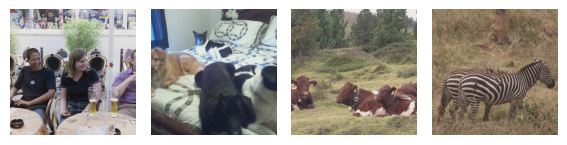

In [33]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Calculate the number of rows needed to display images in a 2-column layout
num_images = len(images)
num_cols = 7
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division to get the required number of rows

# Set up the plot
plt.figure(figsize=(10, num_rows * 3))  # Adjust the figure size as needed

# Loop through and display each processed image in a grid with denormalization
for i, img in enumerate(images):
    # Denormalize the image
    img = img.permute(1, 2, 0)  # Convert (C, H, W) to (H, W, C)
    img = denormalize(img, mean, std)  # Apply denormalization
    img = torch.clip(img, 0, 1)  # Clip to valid range [0, 1] and convert to numpy for display
    img = img.cpu()
    # Add subplot in a 2-column grid
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

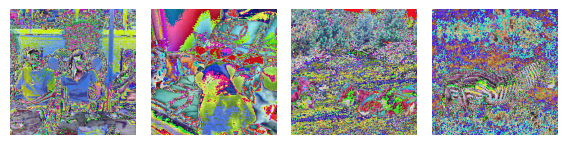

In [34]:
# Set up the plot
plt.figure(figsize=(10, num_rows * 3)) 

# Loop through and display each processed image
for i, img in enumerate(images):
    # Check if the image is a tensor and convert it to a NumPy array if needed
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).cpu().numpy()  # Convert (C, H, W) to (H, W, C)
        img = (img * 255).astype('uint8')  # Convert to [0, 255] range for display

    # Add subplot
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.axis('off')  # Hide the axis

# Show the plot with all processed images
plt.tight_layout()
plt.show()

# 3 - Baseline

In [35]:
##########################################################
# YolottoClip - Just for Zero-Shotting the dataset
##########################################################

class YolottoClip():

    def __init__(self, clip_model, clip_preprocess):
        self.yolo = YOLO("yolov8n.pt")
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess

    def infer_bboxes(self, image_path):
        results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        return bboxes
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        processing = []
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            # proc = self.clip_model.encode_image(processed_img)
            processing.append(processed_img)
        preprocessed = torch.tensor(np.stack(processing))
        # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
        return preprocessed


    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features

    def encode_text(self, text):
        # Encode the text using the CLIP model
        with torch.no_grad():
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    def calculate_best_bbox(self, image_path, text, device):
        self.clip_model.eval()
        best_score = 0
        best_bbox = None
        images = []
        ex_bbox = self.infer_bboxes(image_path)

        for bbox in ex_bbox:
            temp = cv2.imread(image_path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).to(device)
            images.append(image)
        images = torch.stack(images)
        #print(images.shape)

        with torch.no_grad():
            image_features = self.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = self.encode_text(text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            logits_per_image = image_features @ text_features.t()

            #logits_per_image, logits_per_text = self.clip_model(images, text)
            #matching_score = logits_per_text.cpu().numpy()[0]
            probs = torch.sigmoid(logits_per_image)
            best = torch.max(probs)
            idx = torch.argmax(probs)

            if best.float() > best_score:
                best_score = best.float()
                best_bbox = ex_bbox[idx] 
                #print('bbox found is = ' + str(best_bbox))

        return best_score, best_bbox

In [50]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
loc_acc = 0
semsim = 0
ga = 0
overall = 0
errors = 0

cumulative_iou = 0.0
cumulative_recall = 0.0
cumulative_sim = 0.0
iou_threshold = 0.5
correct_bboxes = 0
model = YolottoClip(clip_model=clip_model, clip_preprocess=clip_preprocess)
proc = []
eval_loop = tqdm(dataloader_eval, position=0, leave=True)

with torch.no_grad():
    for _,data in enumerate(eval_loop):
        # try:
            scores = []
            bboxes = []

            texts = data[1]
            print(texts)
            texts = texts.squeeze(1).to(device)
            print(texts)
            #images = data[1].to(device)
            gts = data[1]
            clss = data[2]
            filename = data[3]
            images = data[4]

            batch = len(texts)
            overall += batch

            for i in range(batch):
                stack = [texts[i]]
                stacks = torch.stack(stack)
                score, ebbox = model.calculate_best_bbox(filename[i], stacks, device)
                print(score)
                print(ebbox)
                #print(gts[i])
                # scores.append(score)
                # bboxes.append(ebbox)
                iou = compute_iou(ebbox, gts[i])
                cumulative_iou += iou
                if(iou > iou_threshold):
                    #compare_candidate_bbox(filename,bbox_e, bbox_gt)
                    correct_bboxes += 1
                similarity = score / 100
                cumulative_sim += score

                loc_acc = cumulative_iou / overall
                ga = correct_bboxes / overall
                semsim = cumulative_sim / overall 

                if(len(proc)<9):
                    proc.append(draw_bboxes(filename[i],ebbox,gts[i],score.item()))
        # except:
        #     pass

            #writer.add_scalar("loss x epoch", loc_acc/len(xy_trainPT_loader), e)

        #eval_loop.set_description(f"Localization accuracy = {loc_acc}, Grounding Accuracy = {ga}, Semantic Similarity = {semsim}")


  0%|          | 0/5 [00:00<?, ?it/s]

tensor([[[49406,   320,  6867,   539,  3912,  2403,  3694,  2308, 49407,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0]],

        [[49406,  1449,   537,  1579,  1929,   593,  9074,   744,  9861,   269, 49407,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
              0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0,     0

ValueError: WARNING ⚠️ torch.Tensor inputs should be BCHW i.e. shape(1, 3, 640, 640) divisible by stride 32. Input shape() is incompatible.